In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from ucimlrepo import fetch_ucirepo

print("✅ Bibliothèques importées!")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")


✅ Bibliothèques importées!
Pandas version: 2.3.3
NumPy version: 2.2.6


In [4]:

# Télécharger les données
dataset = fetch_ucirepo(id=938)

# Extraire les données
X = dataset.data.features  # Les symptômes et tests
y = dataset.data.targets   # Les diagnostics

# Fusionner pour analyse complète
df = pd.concat([X, y], axis=1)

print(f"✅ Dataset chargé avec succès!")
print(f"📊 Dimensions: {df.shape[0]} patients, {df.shape[1]} variables")

✅ Dataset chargé avec succès!
📊 Dimensions: 782 patients, 56 variables


In [5]:
# Cellule 3: Aperçu général
print("📋 INFORMATIONS GÉNÉRALES")
print("="*50)

# Voir les types de données
print("\n📊 Types de variables:")
print(df.dtypes.value_counts())

# Voir les noms des colonnes
print(f"\n📑 Noms des colonnes ({len(df.columns)} variables):")
for i, col in enumerate(df.columns, 1):
    print(f"  {i}. {col}")

📋 INFORMATIONS GÉNÉRALES

📊 Types de variables:
object     39
float64    17
Name: count, dtype: int64

📑 Noms des colonnes (56 variables):
  1. Age
  2. BMI
  3. Sex
  4. Height
  5. Weight
  6. Length_of_Stay
  7. Alvarado_Score
  8. Paedriatic_Appendicitis_Score
  9. Appendix_on_US
  10. Appendix_Diameter
  11. Migratory_Pain
  12. Lower_Right_Abd_Pain
  13. Contralateral_Rebound_Tenderness
  14. Coughing_Pain
  15. Nausea
  16. Loss_of_Appetite
  17. Body_Temperature
  18. WBC_Count
  19. Neutrophil_Percentage
  20. Segmented_Neutrophils
  21. Neutrophilia
  22. RBC_Count
  23. Hemoglobin
  24. RDW
  25. Thrombocyte_Count
  26. Ketones_in_Urine
  27. RBC_in_Urine
  28. WBC_in_Urine
  29. CRP
  30. Dysuria
  31. Stool
  32. Peritonitis
  33. Psoas_Sign
  34. Ipsilateral_Rebound_Tenderness
  35. US_Performed
  36. Free_Fluids
  37. Appendix_Wall_Layers
  38. Target_Sign
  39. Appendicolith
  40. Perfusion
  41. Perforation
  42. Surrounding_Tissue_Reaction
  43. Appendicular_Abscess
 

❓ QUESTION 1: Y a-t-il des valeurs manquantes?
⚠️ 56 variables ont des valeurs manquantes!

                        Variable  Manquants  Pourcentage %
                Abscess_Location        769          98.34
          Gynecological_Findings        756          96.68
     Conglomerate_of_Bowel_Loops        739          94.50
           Segmented_Neutrophils        728          93.09
                           Ileus        722          92.33
                       Perfusion        719          91.94
                       Enteritis        716          91.56
                   Appendicolith        713          91.18
                     Coprostasis        711          90.92
                     Perforation        701          89.64
            Appendicular_Abscess        697          89.13
           Bowel_Wall_Thickening        683          87.34
            Lymph_Nodes_Location        661          84.53
                     Target_Sign        644          82.35
                       

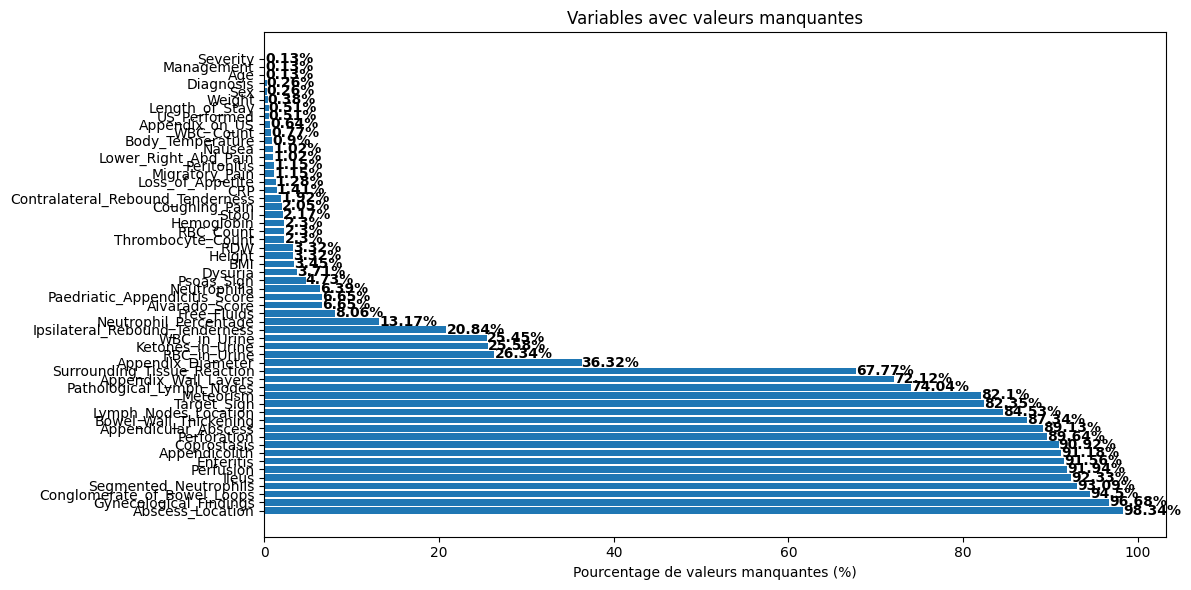

In [6]:
# Cellule 4: ANALYSE DES VALEURS MANQUANTES
print("❓ QUESTION 1: Y a-t-il des valeurs manquantes?")
print("="*60)

# Calculer les manquants
missing = df.isnull().sum()
missing_percent = (missing / len(df)) * 100

# Créer un tableau
missing_data = pd.DataFrame({
    'Variable': df.columns,
    'Manquants': missing.values,
    'Pourcentage %': missing_percent.values.round(2)
})

# Filtrer seulement les variables avec des manquants
missing_with_data = missing_data[missing_data['Manquants'] > 0].sort_values('Pourcentage %', ascending=False)

if len(missing_with_data) > 0:
    print(f"⚠️ {len(missing_with_data)} variables ont des valeurs manquantes!\n")
    print(missing_with_data.to_string(index=False))
    
    # Graphique
    plt.figure(figsize=(12, 6))
    bars = plt.barh(missing_with_data['Variable'], missing_with_data['Pourcentage %'])
    plt.xlabel('Pourcentage de valeurs manquantes (%)')
    plt.title('Variables avec valeurs manquantes')
    
    # Ajouter les pourcentages sur les barres
    for bar in bars:
        width = bar.get_width()
        plt.text(width, bar.get_y() + bar.get_height()/2, f'{width}%', 
                ha='left', va='center', fontweight='bold')
    
    plt.tight_layout()
    plt.show()
else:
    print("✅ AUCUNE valeur manquante détectée!")

In [12]:
# Cellule 5: Statistiques descriptives
print("📊 STATISTIQUES DESCRIPTIVES")
print("="*50)

# Statistiques générales
df.describe()

📊 STATISTIQUES DESCRIPTIVES


,Age,BMI,Height,Weight,Length_of_Stay,Alvarado_Score,Paedriatic_Appendicitis_Score,Appendix_Diameter,Body_Temperature,WBC_Count,Neutrophil_Percentage,Segmented_Neutrophils,RBC_Count,Hemoglobin,RDW,Thrombocyte_Count,CRP
count,781.000000,755.000000,756.000000,779.000000,778.000000,730.000000,730.000000,498.000000,775.000000,776.000000,679.000000,54.000000,764.000000,764.000000,756.000000,764.000000,771.000000
mean,11.346451,18.907012,148.017460,43.172542,4.284062,5.921918,5.253425,7.762651,37.404516,12.670683,71.791163,64.929630,4.799490,13.380497,13.180291,285.252618,31.386900
std,3.529909,4.385331,19.732016,17.390984,2.574057,2.155972,1.958456,2.536671,0.903678,5.366525,14.463656,15.085025,0.499012,1.393271,4.538774,72.494373,57.433854
min,0.000000,7.830000,53.000000,3.960000,1.000000,0.000000,0.000000,2.700000,26.900000,2.600000,27.200000,32.000000,3.620000,8.200000,11.200000,91.000000,0.000000
25%,9.200000,15.725000,137.000000,29.500000,3.000000,4.000000,4.000000,6.000000,36.800000,8.200000,61.400000,54.500000,4.537500,12.600000,12.300000,236.000000,1.000000
50%,11.440000,18.060000,149.650000,41.400000,3.000000,6.000000,5.000000,7.500000,37.200000,12.000000,75.500000,64.500000,4.780000,13.300000,12.700000,276.000000,7.000000
75%,14.100000,21.180000,163.000000,54.000000,5.000000,8.000000,7.000000,9.100000,37.900000,16.200000,83.600000,77.500000,5.020000,14.000000,13.300000,330.000000,33.000000
max,18.360000,38.160000,192.000000,103.000000,28.000000,10.000000,10.000000,17.000000,40.200000,37.700000,97.700000,91.000000,14.000000,36.000000,86.900000,708.000000,365.000000


🎯 ANALYSE DE LA VARIABLE CIBLE
Variable cible trouvée: Diagnosis

Distribution des diagnostics:
Diagnosis
appendicitis       463
no appendicitis    317
Name: count, dtype: int64

Pourcentages:
Diagnosis
appendicitis       59.4
no appendicitis    40.6
Name: proportion, dtype: float64


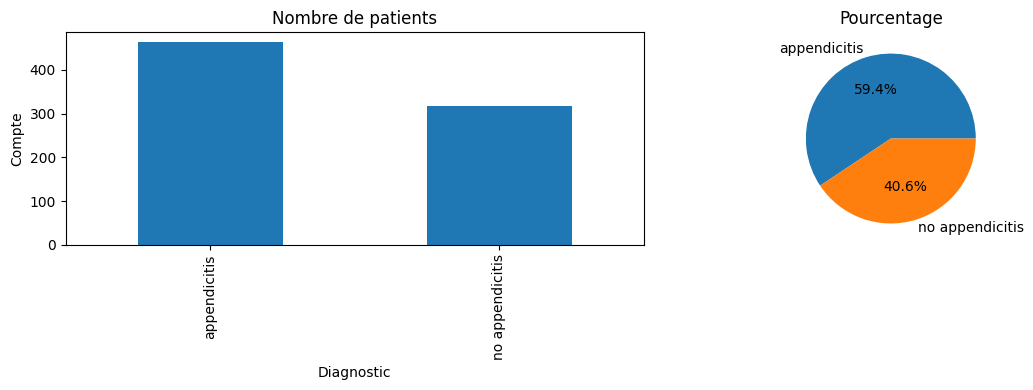


⚠️ Dataset DÉSÉQUILIBRÉ (différence > 10%)


In [13]:
# Cellule 6: Vérification de la variable cible (Diagnosis)
print("🎯 ANALYSE DE LA VARIABLE CIBLE")
print("="*50)

# Chercher la colonne Diagnosis
diagnosis_col = None
for col in df.columns:
    if 'diagnosis' in col.lower():
        diagnosis_col = col
        break

if diagnosis_col:
    print(f"Variable cible trouvée: {diagnosis_col}")
    
    # Distribution
    print("\nDistribution des diagnostics:")
    print(df[diagnosis_col].value_counts())
    print(f"\nPourcentages:")
    print(df[diagnosis_col].value_counts(normalize=True).mul(100).round(1))
    
    # Graphique
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    df[diagnosis_col].value_counts().plot(kind='bar', ax=axes[0])
    axes[0].set_title('Nombre de patients')
    axes[0].set_xlabel('Diagnostic')
    axes[0].set_ylabel('Compte')
    
    df[diagnosis_col].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%')
    axes[1].set_title('Pourcentage')
    axes[1].set_ylabel('')
    
    plt.tight_layout()
    plt.show()
    
    # Vérifier l'équilibre
    counts = df[diagnosis_col].value_counts()
    if len(counts) == 2:
        diff = abs(counts.iloc[0] - counts.iloc[1])
        total = len(df)
        if diff/total < 0.1:  # Moins de 10% de différence
            print("\n✅ Dataset ÉQUILIBRÉ (différence < 10%)")
        else:
            print("\n⚠️ Dataset DÉSÉQUILIBRÉ (différence > 10%)")
else:
    print("⚠️ Colonne 'Diagnosis' non trouvée")
    print("Colonnes disponibles similaires:", [c for c in df.columns if 'diag' in c.lower()])